In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/cleaned_telco_data.csv")

In [3]:
segment_df = df[
    ['Tenure Months',
     'Monthly Charges',
     'Total Charges']
]

In [5]:
segment_df.head()

,Tenure Months,Monthly Charges,Total Charges
0,2,53.85,108.15
1,2,70.70,151.65
2,8,99.65,820.50
3,28,104.80,3046.05
4,49,103.70,5036.30


In [6]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(segment_df)

In [7]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

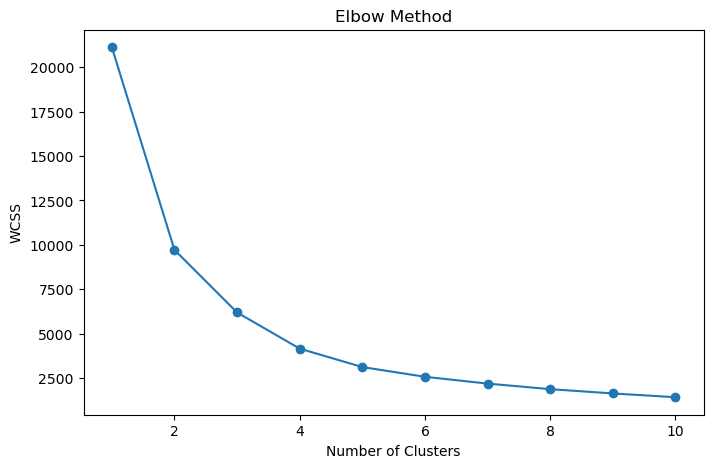

In [8]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [9]:
for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    print("K =",k,
          "Silhouette Score =",score)

K = 2 Silhouette Score = 0.47969586578891316
K = 3 Silhouette Score = 0.4513225090652092
K = 4 Silhouette Score = 0.4719670885081895
K = 5 Silhouette Score = 0.4434591191204936
K = 6 Silhouette Score = 0.4393141478823816
K = 7 Silhouette Score = 0.43074017667440306
K = 8 Silhouette Score = 0.41785885264964145
K = 9 Silhouette Score = 0.4327202281045707
K = 10 Silhouette Score = 0.4349136632895751


In [10]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    scaled_data
)

In [11]:
df['Cluster'] = clusters

In [12]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Cluster
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239,3
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701,0
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,86,5372,0
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003,0
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,89,5340,1


In [13]:
df['Cluster'].value_counts()

Cluster
0    2276
1    1904
3    1704
2    1159
Name: count, dtype: int64

In [14]:
cluster_summary = df.groupby(
    'Cluster'
)[['Tenure Months',
   'Monthly Charges',
   'Total Charges']].mean()

print(cluster_summary)

         Tenure Months  Monthly Charges  Total Charges
Cluster                                               
0            15.424868        80.779657    1253.007239
1            59.530987        93.306224    5548.653887
2            53.585850        34.920147    1836.581320
3            10.228873        31.769131     308.956397


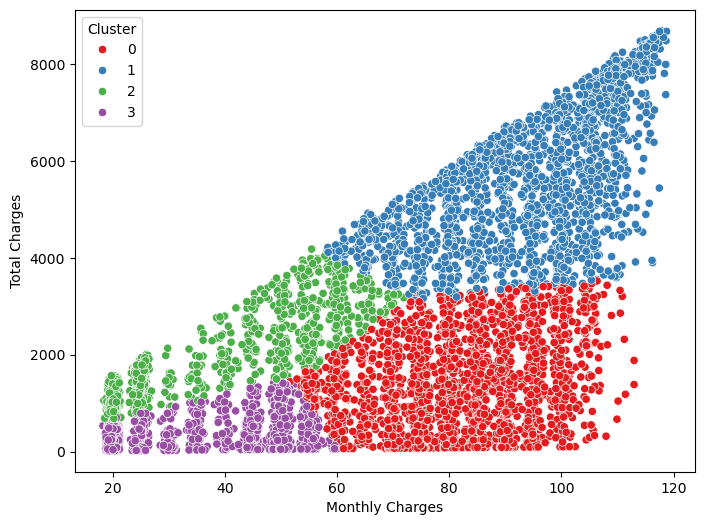

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Monthly Charges',
    y='Total Charges',
    hue='Cluster',
    data=df,
    palette='Set1'
)

plt.show()

In [16]:
cluster_names = {

    0:"High Value Customer",

    1:"Loyal Customer",

    2:"Budget Customer",

    3:"At-Risk Customer"
}

In [17]:
df['Customer Segment'] = (
    df['Cluster']
      .map(cluster_names)
)

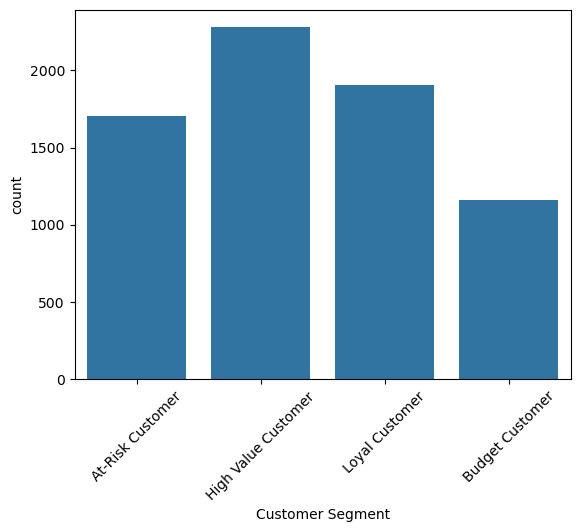

In [18]:
sns.countplot(
    x='Customer Segment',
    data=df
)

plt.xticks(rotation=45)

plt.show()

In [19]:
df.to_csv(
    "../data/customer_segmented.csv",
    index=False
)

In [20]:
pickle.dump(
    kmeans,
    open("../models/kmeans_model.pkl",
         "wb")
)

In [21]:
pickle.dump(
    scaler,
    open("../models/segment_scaler.pkl",
         "wb")
)